# 📊 Análise da Relação Entre Experiência Profissional e Renda

## 🎯 Objetivo
Investigar a relação entre anos de experiência e renda anual, avaliando:

- Se existe correlação estatisticamente significativa
- O comportamento da distribuição salarial
- A capacidade preditiva de um modelo de regressão

## 💼 Aplicação prática
Essa análise pode apoiar:
- Definição de políticas salariais
- Planejamento de carreira
- Estratégias de retenção de talentos

---

Autor: Gabriel  
Área de Interesse: Data Analytics | Data Science

## 1️⃣ Importação das Bibliotecas e Configurações

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import ttest_ind

sns.set(style="whitegrid")

## 2️⃣ Carregamento dos Dados

In [324]:
notebook_path = Path.cwd()
csv_path = notebook_path.parent / 'data' / 'income.csv'
df = pd.read_csv(csv_path)
df.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


## 3️⃣ Entendimento Inicial

In [325]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         50 non-null     int64
 1   experience  50 non-null     int64
 2   income      50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB


,age,experience,income
count,50.000000,50.000000,50.000000
mean,38.860000,8.580000,44864.060000
std,10.719066,4.116121,6916.729587
min,23.000000,0.000000,28559.000000
25%,29.250000,6.250000,41039.250000
50%,39.500000,9.000000,46205.000000
75%,46.000000,12.000000,50064.000000
max,59.000000,14.000000,57092.000000


In [326]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

Linhas: 50
Colunas: 3


In [327]:
df.isnull().sum()

age           0
experience    0
income        0
dtype: int64

O dataframe possui 50 linhas, 3 colunas, e nenhum valor nulo.

## 4️⃣ Análise Exploratória (EDA)

### 📈 Relação Experiência vs Renda

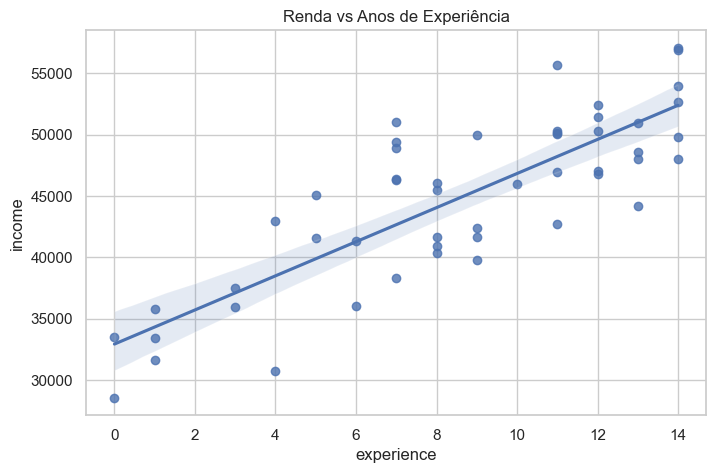

In [328]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='experience', y='income')
plt.title("Renda vs Anos de Experiência")
plt.show()

Observa-se tendência positiva entre experiência e renda, sugerindo possível relação linear.

### 📊 Distribuição da Renda

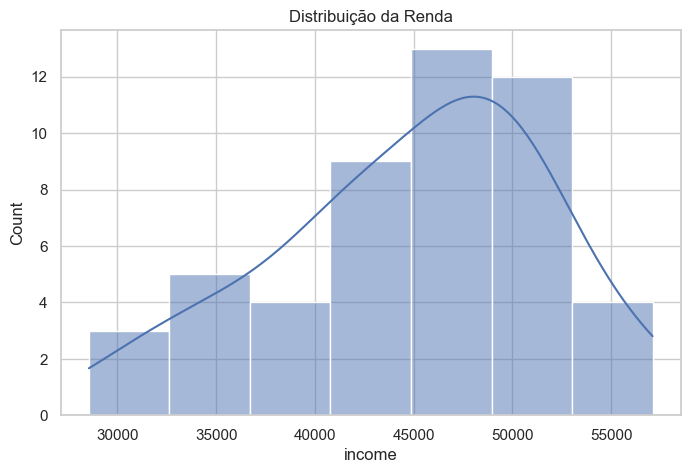

In [329]:
plt.figure(figsize=(8,5))
sns.histplot(df['income'], kde=True)
plt.title("Distribuição da Renda")
plt.show()

A distribuição apresenta leve assimetria. Isso pode impactar modelos lineares.

### 🔗 Correlação

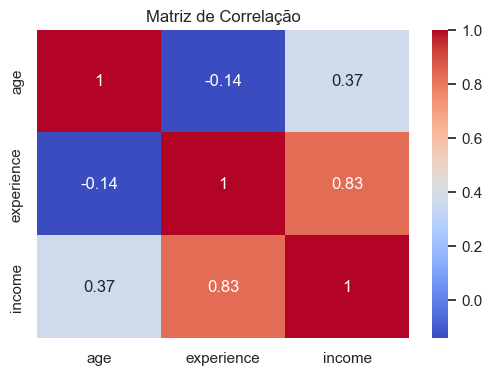

In [330]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()


In [331]:
df[['experience','income']].corr()

,experience,income
experience,1.000000,0.827365
income,0.827365,1.000000


A correlação encontrada foi de aproximadamente 0.83, indicando relação forte.

## 5️⃣ Teste Estatístico

In [ ]:
grupo_1 = df[df['experience'] <= 5]['income']
grupo_2 = df[df['experience'] > 5]['income']

print(f"Média de renda (Até 5 anos): {grupo_1.mean():.2f}")
print(f"Média de renda (Mais de 5 anos): {grupo_2.mean():.2f}")

t_stat, p_value = ttest_ind(grupo_1, grupo_2)

print("t-stat:", t_stat)
print(f"p-value: ", p_value)

t-stat: -6.450492279150332
p-value: 5.1225824023208996e-08


#### 🧠 Teste de Hipótese

H0: Não há diferença significativa entre os grupos  
H1: Existe diferença significativa  

Se p < 0.05 → rejeitamos H0.

Resultado: p = 0.0000000512
Conclusão: Como o p-valor é muito menor que o nível de significância de 0.05, rejeitamos a hipótese nula com 95% de confiança. Os dados fornecem evidências estatísticas robustas de que profissionais com mais de 5 anos de experiência possuem uma renda média superior. O t-statistic negativo (-6.45) confirma que a média do primeiro grupo (menos experientes) é significativamente menor que a do segundo.

## 6️⃣ Modelagem Preditiva

### 🔹Separação Treino/Teste

In [333]:
X = df[['experience']]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 🔹Treinamento

In [334]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### 🔹Avaliação

In [335]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("MAE:", mae)

R²: 0.6541309294744846
MAE: 3300.067883431622


### 🔹Interpretação

O modelo apresentou R² de 0.65, indicando que 65% da variabilidade da renda pode ser explicada apenas pelos anos de experiência.

O erro médio absoluto é de aproximadamente R$ 3.300, indicando que as previsões apresentam variação média nesse valor.

### 📉 Real vs Previsto

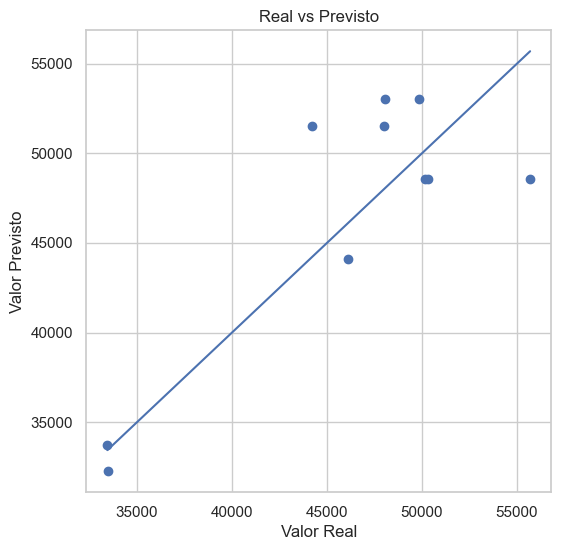

In [336]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Real vs Previsto")
plt.show()

## 7️⃣ Interpretação do Modelo

In [337]:
coeficiente = model.coef_[0]
intercepto = model.intercept_

print(f"Coeficiente experiência: {coeficiente:.2f}")
print(f"Intercepto: {intercepto:.2f}")

Coeficiente experiência: 1481.76
Intercepto: 32261.65


Para cada ano adicional de experiência, a renda aumenta em média R$ 1.481,76.

O intercepto representa a renda estimada para zero anos de experiência.

## 8️⃣ Análise de resíduos

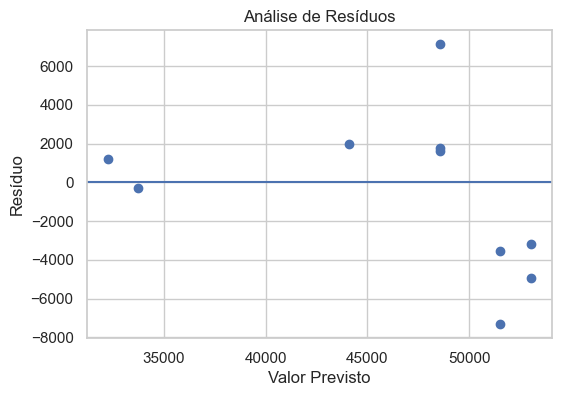

In [338]:
residuos = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuos)
plt.axhline(0)
plt.xlabel("Valor Previsto")
plt.ylabel("Resíduo")
plt.title("Análise de Resíduos")
plt.show()

## 9️⃣ Limitações do Estudo

- Apenas uma variável explicativa
- Não considera formação acadêmica
- Não considera setor de atuação
- Possível viés amostral

## 🔟 Conclusão Final

A análise identificou forte correlação positiva entre experiência e renda.

O modelo de regressão indica que cada ano adicional de experiência está associado a um aumento médio de aproximadamente $X na renda anual.

Apesar do modelo capturar parte relevante da variação salarial, outras variáveis como educação, setor e localização provavelmente também influenciam a renda.